<a href="https://colab.research.google.com/github/r-okotie179/charity-idea/blob/main/charity_idea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# charity-idea
I would like to construct some backend such that it can help with resource allocation for clubs in local councils, such that directed funding could take place to maximise positive effects in the community. It would benefit the youth (for whom I'd like to volunteer for) and the local council (by saving money in the long run).

### Information about club nodes
`location` - where the clubs are on the map; could be used to more contextually place clubs in areas of varying levels of deprivation (e.g. the IDACI scale)

`topic` - what is the club providing; intially separated in topics that students can select but will be developed with a more contextual understanding of a user's preference that can then be aligned with available clubs (it would have to be more data rich and not one source)

`max-capacity` - what is the venue size; how many children can be allocated

`cost` - how much does the admission cost cost for someone applying



---
#### not yet added
`staff-numbers` - what is the allocation of staff required (maybe even volunteers required).

`running-costs` - how much is the council paying (per time period). Since I would like the majority of these clubs to be free for the user (and paid for by charities/govs/companies) this would be a better point to add

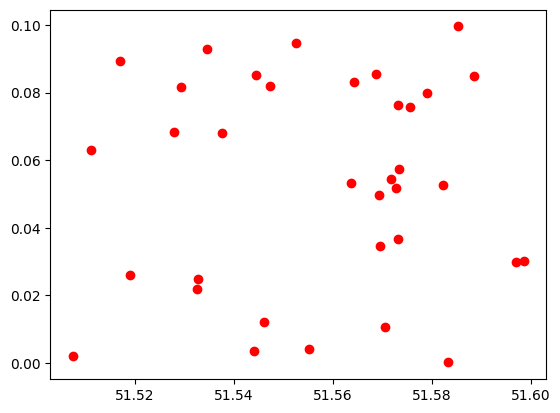

In [ ]:
import pandas as pd
import random as rand
import numpy as np
import matplotlib.pyplot as plt

# graph G will be bipartite in form (V, E), V = the union of students (U) and clubs (W)
## defining the clubs, W
def clubs(n):
    '''
    This will have attributes: ID, topics (an issue for later since there could be overlapping topics, what is an important topic, etc), max capacity, cost (per term?), position (latitutde and longitude)
    '''
    W = []
    topics = ["maths tutoring", "extension maths", "admissions preparation", "extension physics", "linguistics", "coding club", "finance society", "book club"] # a critique of this is its vagueness and what it is actually targeting; that needs to be considered in such a model
    # also, wrt to topics, they need to be grouped into certain themes, which could be a separate issues
    max_cap = np.arange(5, 45, 5).tolist() # so that each dtype would be an int
    cost_options = [0,0,0,0,0,5,5,5,5,10,10,10,50,150,150,250]
    for i in range(n):
        W_subset = []
        ID = i
        topic = rand.choice(topics)
        max_capacity = rand.choice(max_cap)
        cost = rand.choice(cost_options)
        position = (rand.uniform(51.5, 51.6), rand.uniform(0.0, 0.1))
        W.append((ID, topic, max_capacity, cost, position))
    return W # a list of length n
clubs = clubs(35)
#print(W) # list of the synthetic data
df_clubs = pd.DataFrame(clubs, columns=['Club-ID', 'Topic', 'Capacity', 'Cost', 'Position']) # made a pandass dataframe
pos = df_clubs['Position'].to_numpy()
x,y = zip(*pos)
plt.scatter(np.array(x), np.array(y), color='red')

### Information about student nodes

`location` -- same as above

`topic` -- topics that they are interested, random selection of a random number of interests

`interest-weighting` -- random number between 1 and 10 for the length of  list of interests

`budget-limit` -- overall thing, might use knapsack algorithm for choosing optimal placings but this would have to consider time constraints also... Would be cool to return to 6.002 when I have a laptop again for this

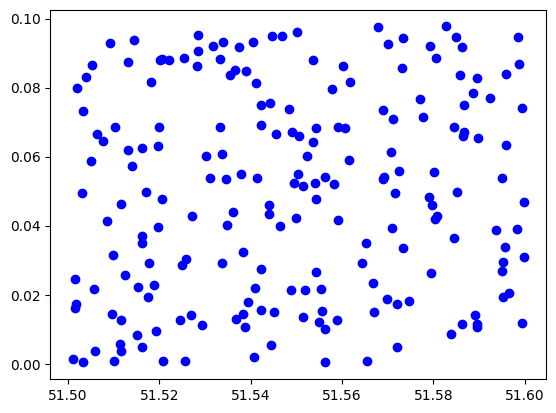

In [ ]:
def students(n):
    '''
    This will include the components for the students to use as inputs
    '''
    U = [] # both W and U are subsets of the set of nodes, V
    topics = ["maths tutoring", "extension maths", "admissions preparation", "extension physics", "linguistics", "coding club", "finance society", "book club"] # a critique of this is its vagueness and what it is actually targeting; that needs to be considered in such a model
    for i in range(n): # for each student intstance
        U_subset = []
        ID = i
        topic_no = rand.randint(1,5) # arbitrary maximum
        topic_set = list(set([rand.choice(topics) for i in range(topic_no)])) # simple logic that allows duplicates; they will be reduced in later filtering so the number will unlikely be 5
        interest_weighting = [rand.randint(4,10) for i in range(topic_no)] # minimum is arbitrary; why pick a choice it is a 2 tho
        budget_limit = np.floor(np.random.exponential(scale=10, size=1)).astype(int) # as integer in case of down stream issues, having a consistent data type would reduce that (prob)
        position = (rand.uniform(51.5, 51.6), rand.uniform(0.0, 0.1))

        U.append((ID, topic_set, interest_weighting, budget_limit, position))
    return U

students = students(200)
df_students = pd.DataFrame(students, columns=['Student-ID', 'Topics-Set', 'Interest-Weighting', 'Budget-Limit', 'Position'])
pos = df_students['Position'].to_numpy()
a,b = zip(*pos)
plt.scatter(np.array(a), np.array(b), color='blue')

Below will be the logic for the edges connecting the students to clubs.

Visually, not much will be extracted from that graph, yet I would like some way of this stored data form of:

$$G = (V,E)$$\
$$W \cup U \subseteq {V}$$

After this, I could explore different forms of representation.

In [ ]:
def weighting(dist, cost):
  # I need some way of including the strength of intterest
  # the best way would be for comparisons between the student's different clubs in different topics, iif there is a restricted amount of time that they can attend clubs (e.g. only Saturdays)
  # therefore, the interest-weighting aspect is currently not that useful (but another note for future)

  # simple, balanced and normalised weighting
  weight = (np.array(dist) * .5) + (np.array(cost) * 0.5)
  return weight # hopefully outputting a list

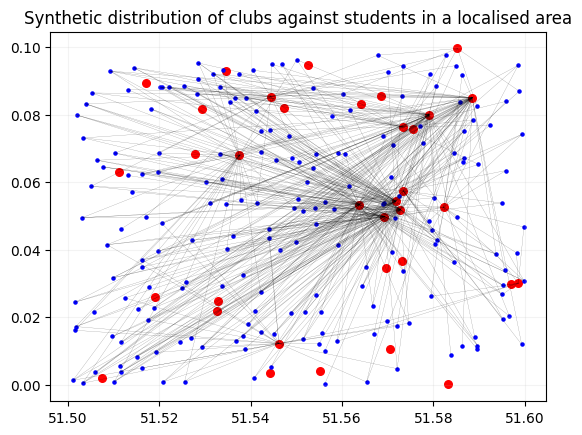

In [ ]:
edge_list = []

for i in range(len(df_students)):
  student_i = df_students.loc[i]
  for topic in student_i["Topics-Set"]:
    potential_clubs = df_clubs[df_clubs['Topic'].apply(lambda x: topic in x)]
    club_position_array = np.array(potential_clubs["Position"].tolist()) # needed in list form otherwise a tuple would subtract from a list, which caused an error
    n = len(club_position_array)
    k = student_i["Position"]
    q = np.tile(k, (n,1)) # x carries the position coordinates, whilst n is an integer number
    # now I am calculating the distance between the places
    dist_matrix = club_position_array - q
    club_dist = np.linalg.norm(dist_matrix, axis=1) # for every row it finds the magnitude, better than another for loop
    # I am not sure how to include the strenght of interest into this model now...
    club_cost = np.array(potential_clubs["Cost"].tolist())
    weight = weighting(club_dist, club_cost)
    lowest_weight_index = np.argmin(weight)
    output_club = potential_clubs.iloc[lowest_weight_index]
    #print(output_club)

    # plotting these edges together
    abba = k
    beta = output_club["Position"]
    xx = [abba[0], beta[0]]
    yy = [abba[1], beta[1]]
    plt.plot(xx,yy, lw=.15, color='black', alpha=0.55)

    # storing these edges with specific indexing of (i,j)
    # have the listed quality in this form: [(i,j), weight]
    edge = [[student_i["Student-ID"], output_club["Club-ID"]], weight[lowest_weight_index]]

    edge_list.append(edge)

df_edges = pd.DataFrame(edge_list, columns=["ID", "Weight"])

plt.scatter(x,y,color='r',s=30)
plt.scatter(a,b,color='b',s=5)
plt.grid(alpha=.15)
plt.title("Synthetic distribution of clubs against students in a localised area")
plt.show()

### Networkx
Rather than storing the data

- add networkx dependency
- read and take notes on how to do graph clustering (different techniques, why i need it, how it actually works)
- rewrite intention with this model and what i want from it

In [ ]:
import networkx as nx

In [ ]:
G = nx.Graph() # I will work with DiGraphs with the disease model

for _, student in df_students.iterrows():
  # add node with the vector qualities as the student dataframe
  # topics, interest, budget, position (to add data visibility later)
  G.add_node(f"S_{student['Student-ID']}",
    node_type="student",
    topics=student['Topics-Set'],
    interest_weighting=student['Interest-Weighting'],
    budget=student['Budget-Limit'],
    position=student['Position']
  )
for _, club in df_clubs.iterrows():
  G.add_node(f"S_{club['Club-ID']}",
    node_type="club",
    topic=club['Topic'],
    capacity=club['Capacity'],
    cost=club['Cost'],
    position=club['Position']
  )
for _, edge in df_edges.iterrows():
  student_id, club_id = edge['ID']
  edge_weight = edge['Weight']
  G.add_edge(f"S_{student_id}", f"C_{club_id}", weight=edge_weight)

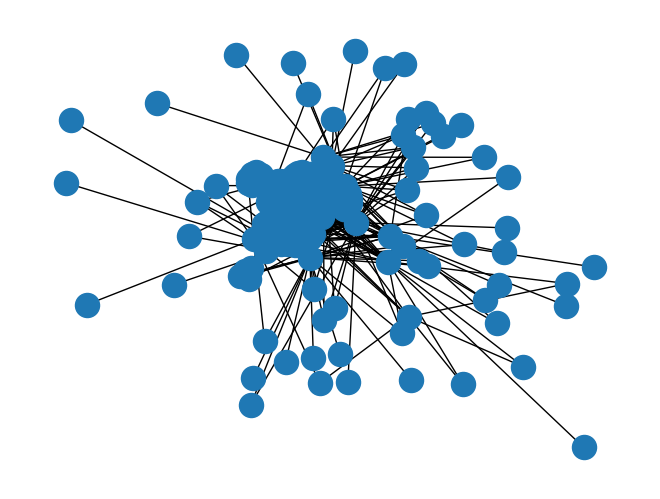

In [ ]:
nx.draw(G)
plt.show()

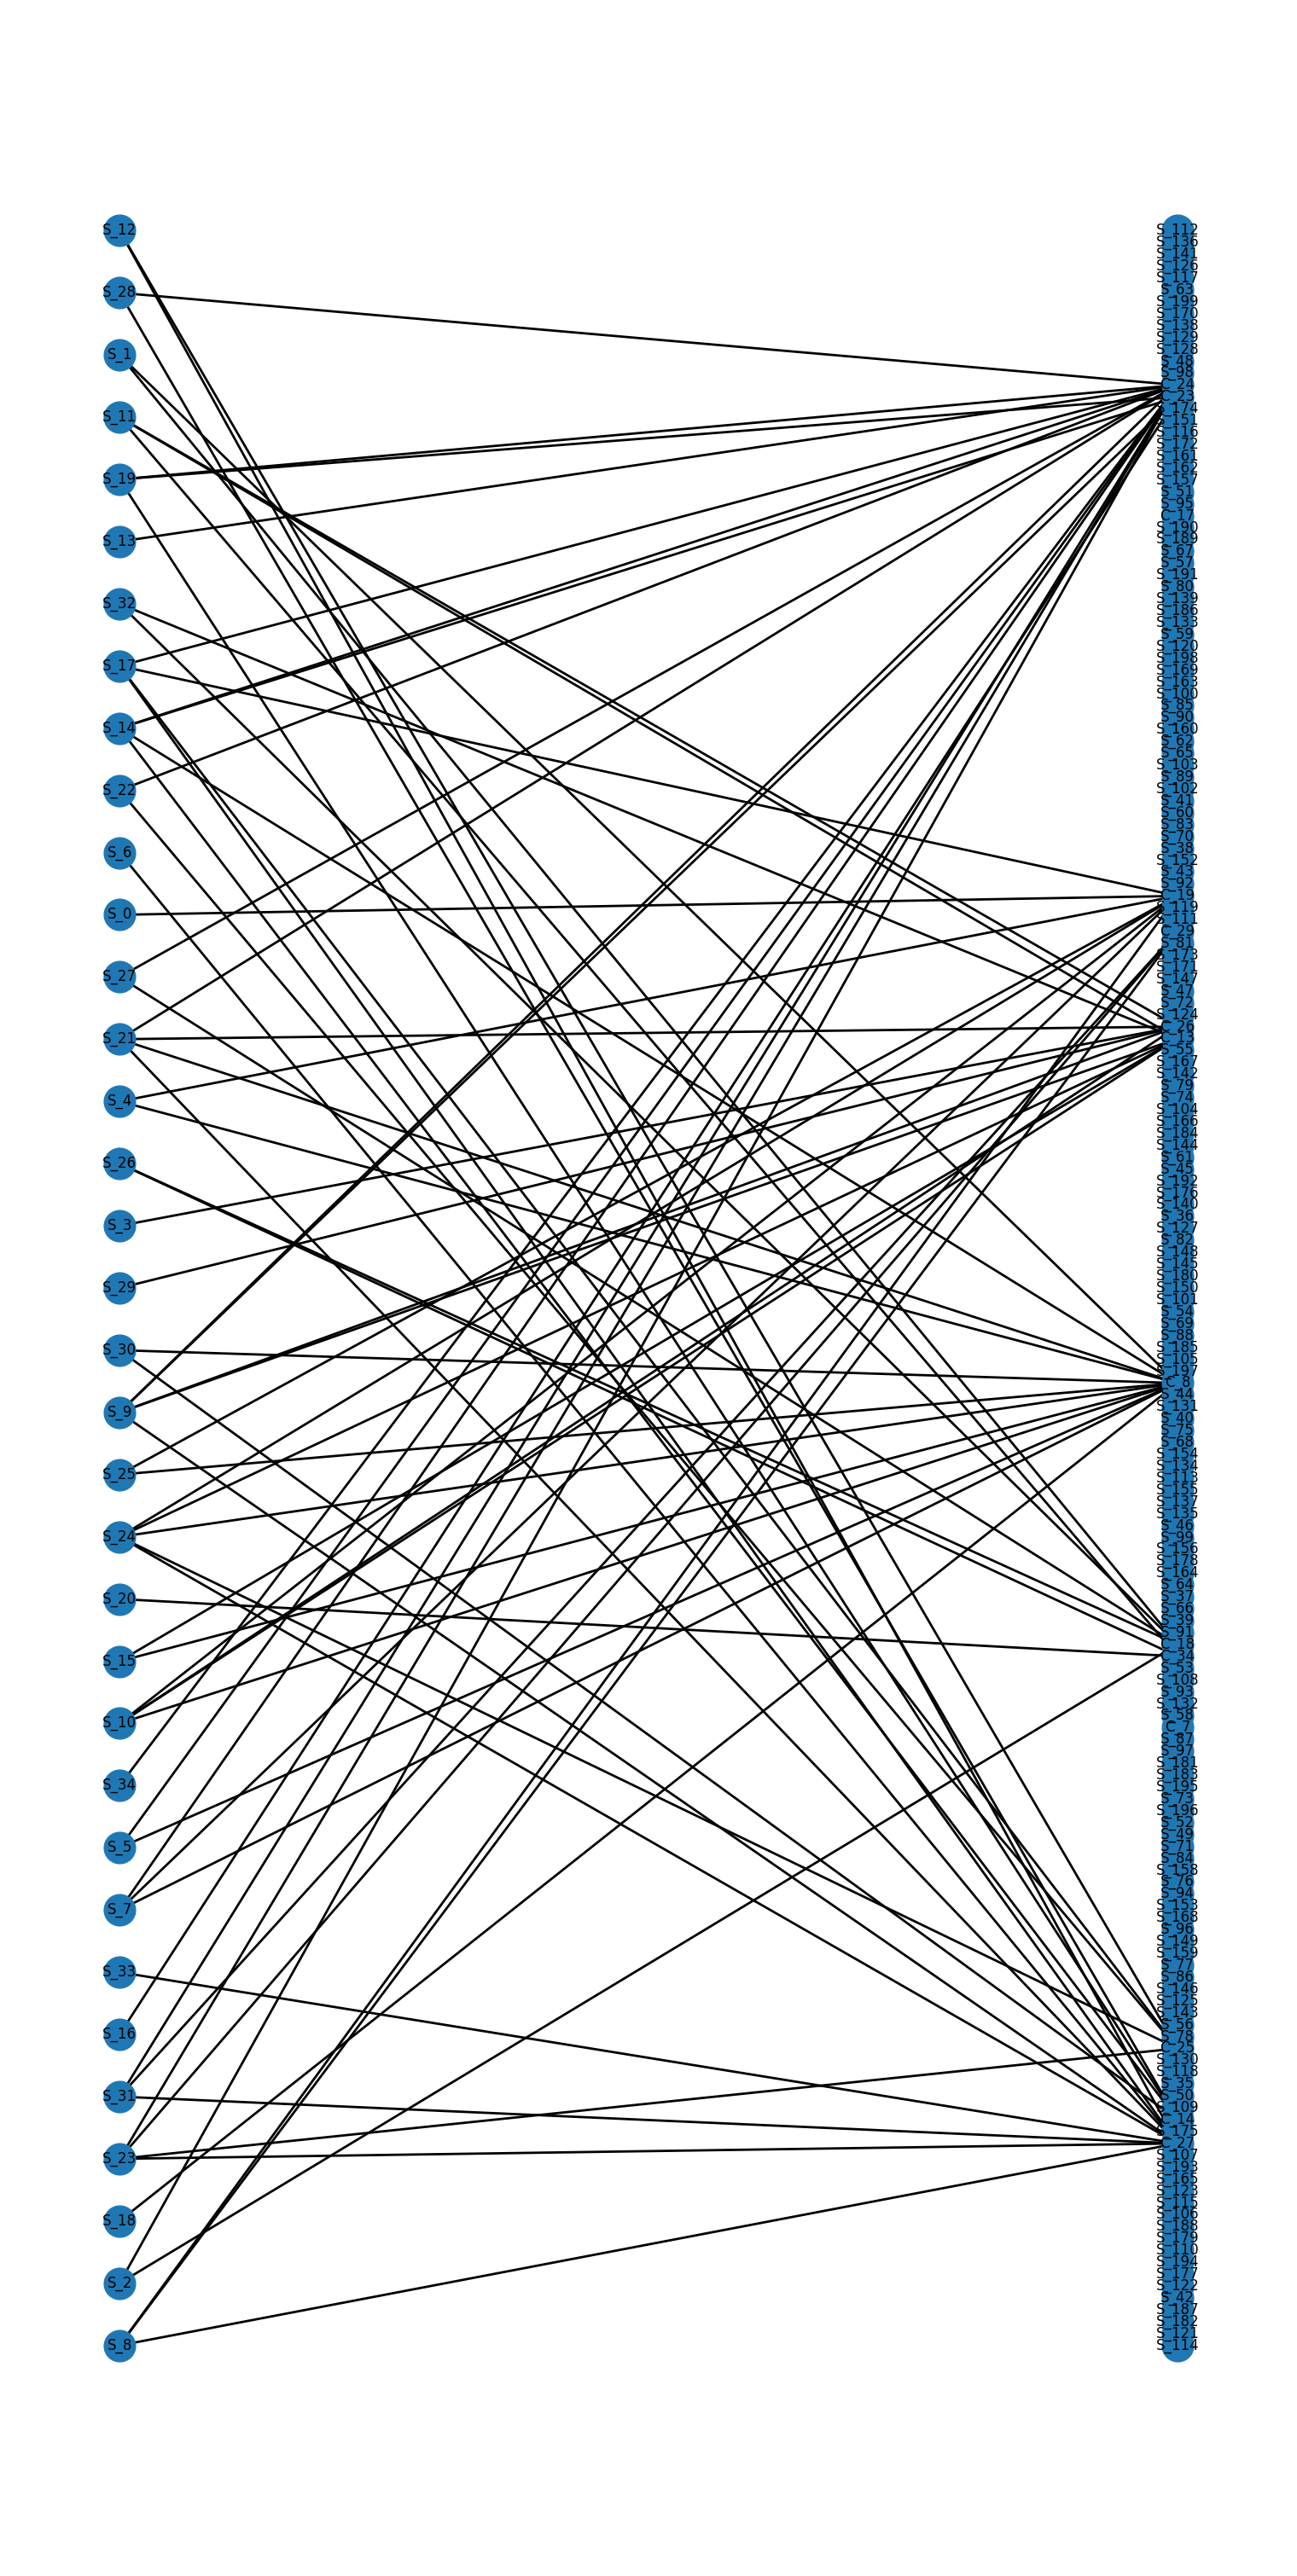

In [ ]:
club_nodes = [
    node for node, data in G.nodes(data=True) if data.get("node_type") == "club"
]

pos = nx.bipartite_layout(G, club_nodes)

plt.figure(figsize=(15, 30))
edge_widths=2
nx.draw(
    G,
    pos=pos,
    with_labels=True,
    node_size=700,
    width=edge_widths,
)
plt.show()

### Graph Clustering

Understanding mathematically the different approaches to developing clusters in a graph.

It will start with exclusively using the edges that connect them (and their weights) but will develop to the more personal qualities that the nodes contain and how they can be included.

I started out trying to understand different approaches to clustering: below will be my explanation.

#### k-means clustering
This is a recursive algorithm that starts with a guess, and optimises this guess until reaching some local optimum. An issue with this is that I do not know how many clusters are present in my data, so I don't know how useful this will be.

```
1. Have an initial guess at the composes the set of k-clusters

2. Find the centroids of these clusters (the nodes which are in the centre/most central to these clusters)

3. Find the best cluster from these calculated centroids: for a given node, associate the node with the centroid to which it is closest to

4. Recurse (i.e. repeat step 1 until no further changes occur).

```

As a note, one simple way of calculating centroids is:

$$c_i = \min{c \in N} \sum{||x_i - c||}^2$$

Effectively, the node in a cluster whose distance is the minimum across all other nodes in said cluster.

Another point is that I would not know whether this is an optimal solution, since it is dependent on my first guess (and I don't know whether it will converge on a solution). I can explore this further, however, since I only used a brief read of the Wiki and the 18.065 Gilbert Strang Lecture (34, I think).

### spectral clustering
*This is one that I understand less so this explanation will be improved upon later"

You find the Laplacian matrix from the network that you have constructed such that:

$$L = D-A$$

From this Laplacian (nothing to do with the transform, something about something else), you should find the eigenvector from this matrix.

An eigenvector is a vector that only gets linearly transformed following a matrix operation:

$$Ax = \lambda x$$

$\lambda$ is the eigenvalue and just says how much the vector has scaled following the transformation.

Due to some property, the smallest eigenvector from the $L$ is a constant vector but the second smallest is the Fielder eigenvector. Using this, the components of values from the vector can be partitioned (having been associated to given nodes in the network) and that is how your cluster is formed.

I still think it has the same issues as k-means (but less, although you'd need k-means to deal with this).

So now I will move onto community detection for my thing.

# Phase I: Student-side
Will try to make a student-side clustering algorithm, written all by myself and then having iterations and pushback from some experts (if they respond) and LLMs.

```
# get the set of student-nodes

# edge weights between students determined by:
## discrete number of topics shared
## minimising distance between shared topics and associated interest weighting*
## similarity in budget
### edge weight must be between 0 and 1

# scale of search will be k-depth tree (can be varied with a slider, start with 10)

# slider parameters:
## edge pruning (depending on a varying parameter, 0 < r < 1)
## k-depth tree (how extensive in the graph will it search, it **shouldn't** do this by distance, the search should be random across the graph)
```

In [ ]:
# student nodes
student_nodes = [
    node for node, data in G.nodes(data=True) if data.get("node_type") == "student"
]

#

With these created edges, clustering can occur.

In [ ]:
'''
with these created edges,
'''

# Additional Notes
*This section will also include some AI declarations*

Below is the plot of one of the distributions I took for what each person's budget limit would be; the assumption is that this region has mixed levels of deprivation  but is on the wealthier side... I would like this to tend to providing free opporutnities and potentially modelling the positive externalities.

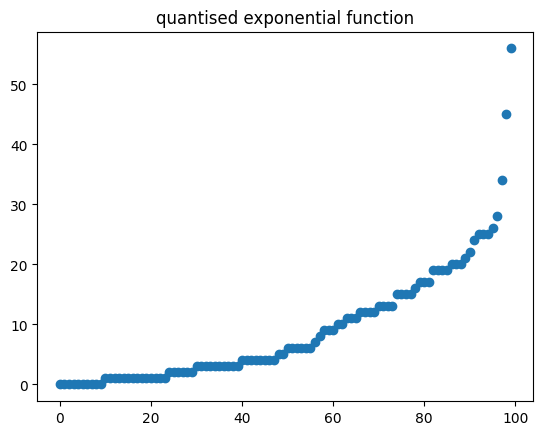

In [ ]:
# this is the distribution used for the cost allocation; most people are around 10 pounds but a few can splurg a little more. I took the floor of the real results
values = np.random.exponential(scale=10, size=100)
x = [i for i in range(len(values))]
#print(x)
values = np.floor(sorted(values))
plt.scatter(x, values)
plt.title("quantised exponential function")
plt.show()
#print(values)

### LLMs for intent
How could LLMs be used to extract the intent of clubs. For example if a user's desire from a survey is "to have a club where I could learn a new sport, maybe meet some people. I also want to get better at maths but I'm quite open to learning outside of school since I think it would be useful", how could this be reliably decomposed and matched to potential clubs in the network (or stored under one of the gaps that could be flagged).


### Collaboration
Maybe after the September deadline, but how should existing collaborations work in understanding from first hand experience what people would want from youth clubs/centres and how such a site could be useful.

### Probability Aspect

There is a paper on NetHOPs which I will more closely deconstruct to see how graphs can be visualised dynamically as probabilities along their edges change; potentially as response to input (like disease propagation).

This context will focus on tending towards a stable cluster under uncertainty, however, and will take different approaches to defining this uncertainty to begin with.